# Overview and Key Insights: Coursera Exploratory Data Analysis
**Overview: The goal of this Pandas code notebook is Exploratory Data Analysis (EDA) of a Coursera Data Set. The analysis includes investigation of data cleaning and then performing EDA in several areas including the following:**
* #### Data Types, Summary data, and Data Cleaning
    *  Data Types
        * The data set has 891 rows and 7 columns
        * 1 float64, 1 int64, 5 objects columns
        * int64 column is unnamed
        * float64 is course_rating column
        * Object columns include course_title, course_organization, course_Certificate_type, course_difficulty, and course_students_enrolled
            * **course_students_enrolled transformed to float64**
    * Missing and Duplicates
        * There are no missing data or duplicates in the data set
    * Key Column Information
        * Unique elements in course_Certificate_type are 'SPECIALIZATION', 'COURSE', 'PROFESSIONAL CERTIFICATE'
        * Unique elements in course_difficulty are 'Beginner', 'Intermediate', 'Mixed', 'Advanced'
* #### Explorations and Insights:
    * Course Organization
        * What are the top 25 organizations by course count?
            * **Organization Reputations and Robustness Matter**
        * What types of courses are these organizations offering?
            * **Courses (as opposed to specializations and professional certifications) are the majority of certification types**
    * Course Ratings
        * What is the range of course ratings?
            * **Course ratings tend to cluster between 4.6 and 4.8**
        * What is the range of ratings by course difficulty?
            * **The majority of courses are beginner and they are rated well**
    * Course Titles 
         * What are the course titles of the top and bottom 50 rated courses?
            * **Popularity and rating may be correlated but not directly**
    * Course Enrollment
        * What is the course enrollment by course rating?
            * **Comparisons of individual courses by enrollment and same rating are also meaningful**
    * Additional (Keywords)
        * What are the most common two word phrases found in course titles?
            * **'Data science', 'machine learning', and 'google cloud' are the most common phrases in course titles**
        * What is the enrollment for the courses with the most common two word phases?
            * **'Data science' and 'machine learning' are driving robust enrollment numbers**


In [62]:
# Importing various libraries that may be useful for EDA 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [63]:
# Uploading data set and reading first few rows
# Looking for data types
csera_data = pd.read_csv('coursea_data.csv')

## Data Types, Summary Data, and Data Cleaning

In [64]:
csera_data.head()

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


In [65]:
csera_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                891 non-null    int64  
 1   course_title              891 non-null    object 
 2   course_organization       891 non-null    object 
 3   course_Certificate_type   891 non-null    object 
 4   course_rating             891 non-null    float64
 5   course_difficulty         891 non-null    object 
 6   course_students_enrolled  891 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 48.9+ KB


In [66]:
csera_data.describe(include = "object")

,course_title,course_organization,course_Certificate_type,course_difficulty,course_students_enrolled
count,891,891,891,891,891
unique,888,154,3,4,205
top,Developing Your Musicianship,University of Pennsylvania,COURSE,Beginner,120k
freq,2,59,582,487,22


In [67]:
csera_data.course_Certificate_type.unique()

array(['SPECIALIZATION', 'COURSE', 'PROFESSIONAL CERTIFICATE'],
      dtype=object)

In [68]:
csera_data.course_difficulty.unique()

array(['Beginner', 'Intermediate', 'Mixed', 'Advanced'], dtype=object)

In [69]:
# Looking for missing data
print("\nMissing values per column:\n", csera_data.isnull().sum())


Missing values per column:
 Unnamed: 0                  0
course_title                0
course_organization         0
course_Certificate_type     0
course_rating               0
course_difficulty           0
course_students_enrolled    0
dtype: int64


In [70]:
# Is any course, such as 'Developing Your Musicianship', duplicated by title + org + certificate type?
csera_data.duplicated(subset = ['course_title', 'course_organization', 'course_Certificate_type']).sum()

np.int64(0)

In [71]:
# Does any organization have more than one course with the same certificate type and difficulty combination?
csera_data.duplicated(subset = ['course_organization', 'course_Certificate_type','course_difficulty']).sum()

np.int64(523)

**Result:** 523 rows share an organization/certificate-type/difficulty combination with an earlier row — expected given how few certificate types and difficulty levels exist relative to 891 courses, and consistent with prolific organizations (e.g., IBM, Google) offering many courses at the same difficulty tier.

In [72]:
# Normalize and shorten column titles
csera_original = pd.DataFrame(csera_data)

print("Original DataFrame columns:")
print(csera_original.columns)

# Rename columns and drop leftover index column from original CSV export
csera_cleaned = (
    csera_original
    .drop(columns=['Unnamed: 0'])  
    .rename(columns={
        'course_Certificate_type': 'certificate_type',
        'course_students_enrolled': 'students_enrolled'
    })
)


csera_data = csera_cleaned

print("\nDataFrame columns after renaming:")
print(csera_data.columns)

print("\nFirst 3 rows of the cleaned DataFrame:")
display(csera_data.head(3))

Original DataFrame columns:
Index(['Unnamed: 0', 'course_title', 'course_organization',
       'course_Certificate_type', 'course_rating', 'course_difficulty',
       'course_students_enrolled'],
      dtype='object')

DataFrame columns after renaming:
Index(['course_title', 'course_organization', 'certificate_type',
       'course_rating', 'course_difficulty', 'students_enrolled'],
      dtype='object')

First 3 rows of the cleaned DataFrame:


,course_title,course_organization,certificate_type,course_rating,course_difficulty,students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k


In [73]:
# Normalize lowercase spellings of certificate types

# Create a copy to demonstrate without altering the original DataFrame for this example
df_replace = csera_data.copy()

# Replace specific values
df_replace['certificate_type_renamed'] = df_replace['certificate_type'].replace({
    'SPECIALIZATION': 'Specialization',
    'COURSE': 'Course',
    'PROFESSIONAL CERTIFICATE': 'Professional Certificate'
})

display(df_replace[['certificate_type', 'certificate_type_renamed']].head())
csera_data['certificate_type'] = df_replace['certificate_type_renamed']
certificate_type = csera_data['certificate_type'] 
certificate_type

,certificate_type,certificate_type_renamed
0,SPECIALIZATION,Specialization
1,COURSE,Course
2,COURSE,Course
3,COURSE,Course
4,COURSE,Course


0      Specialization
1              Course
2              Course
3              Course
4              Course
            ...      
886    Specialization
887            Course
888    Specialization
889    Specialization
890    Specialization
Name: certificate_type, Length: 891, dtype: object

In [74]:
# First, create a copy of the column to work with
students = csera_data['students_enrolled'].str.lower().str.strip()

# Handle commas in all values
students = students.str.replace(',', '')

# Create masks for 'k' and 'm' values
k_mask = students.str.contains('k')
m_mask = students.str.contains('m')

# Remove 'k' and 'm' and convert to float
students = students.str.replace('k', '').str.replace('m', '')
students = students.astype(float)

# Apply multipliers based on masks
students = students.mask(k_mask, students * 1000)
students = students.mask(m_mask, students * 1000000)

# Assign back to the dataframe 
csera_data['students_enrolled'] = students


# check the dtype is now float
print(csera_data['students_enrolled'].dtype)

# check the first 10 values 
print(csera_data['students_enrolled'].head(10))

# check min and max make sense
print(csera_data['students_enrolled'].describe())



float64
0      5300.0
1     17000.0
2    130000.0
3     91000.0
4    320000.0
5     39000.0
6    350000.0
7      2400.0
8     61000.0
9     12000.0
Name: students_enrolled, dtype: float64
count    8.910000e+02
mean     9.055208e+04
std      1.819365e+05
min      1.500000e+03
25%      1.750000e+04
50%      4.200000e+04
75%      9.950000e+04
max      3.200000e+06
Name: students_enrolled, dtype: float64


# Exploration and Insights

### Course Organization

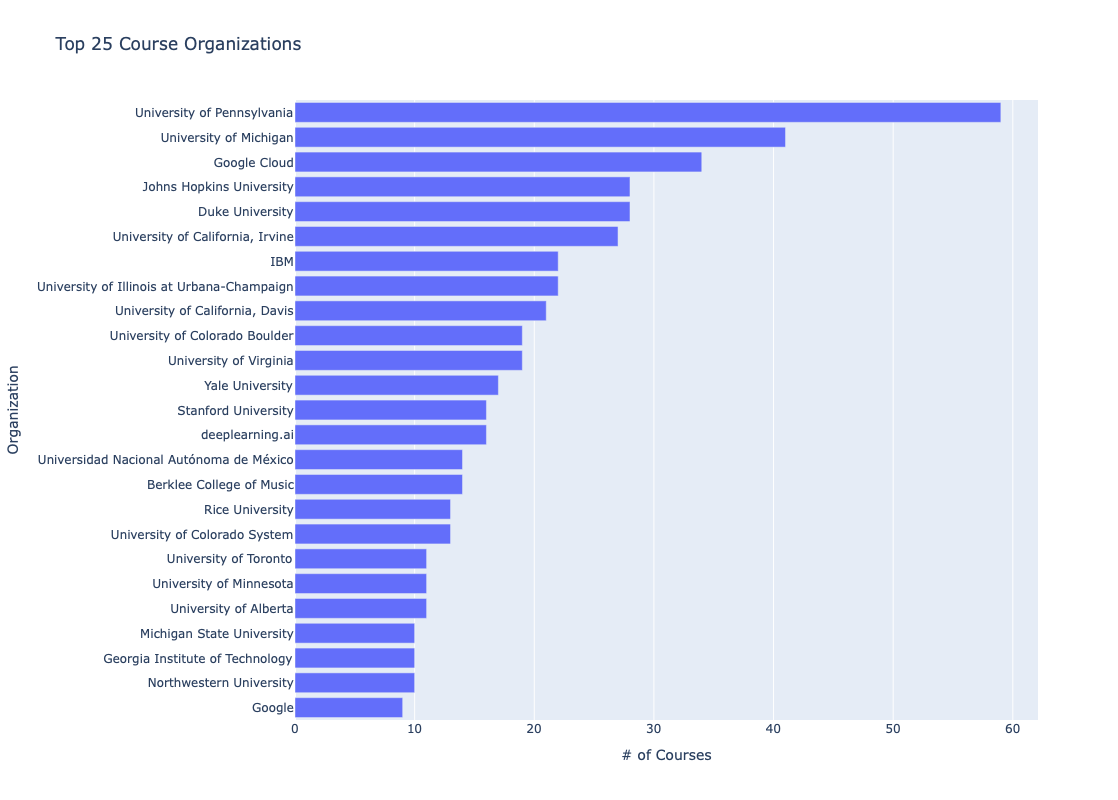

In [75]:
# What are the top 25 organizations by course count?
top25_orgs = (csera_data['course_organization']
                .value_counts()
                .head(25)
                .reset_index()
                .sort_values('count', ascending= True))
fig = px.bar(top25_orgs, 
             x='count', 
             y='course_organization',
             title='Top 25 Course Organizations',
             labels={
                'course_organization': 'Organization',
                'count':'# of Courses'
                
    },
             width = 1000,
             height = 800
             )
fig
fig.show()

**Course Organization Reputations and Robustness Matter**
* People may be coming to Coursera with particular course organizations in mind because of their reputation and/or robustness of offerings. An additional exploration that could be done here is exploring how many of these courses build upon each other or are within similar areas. 

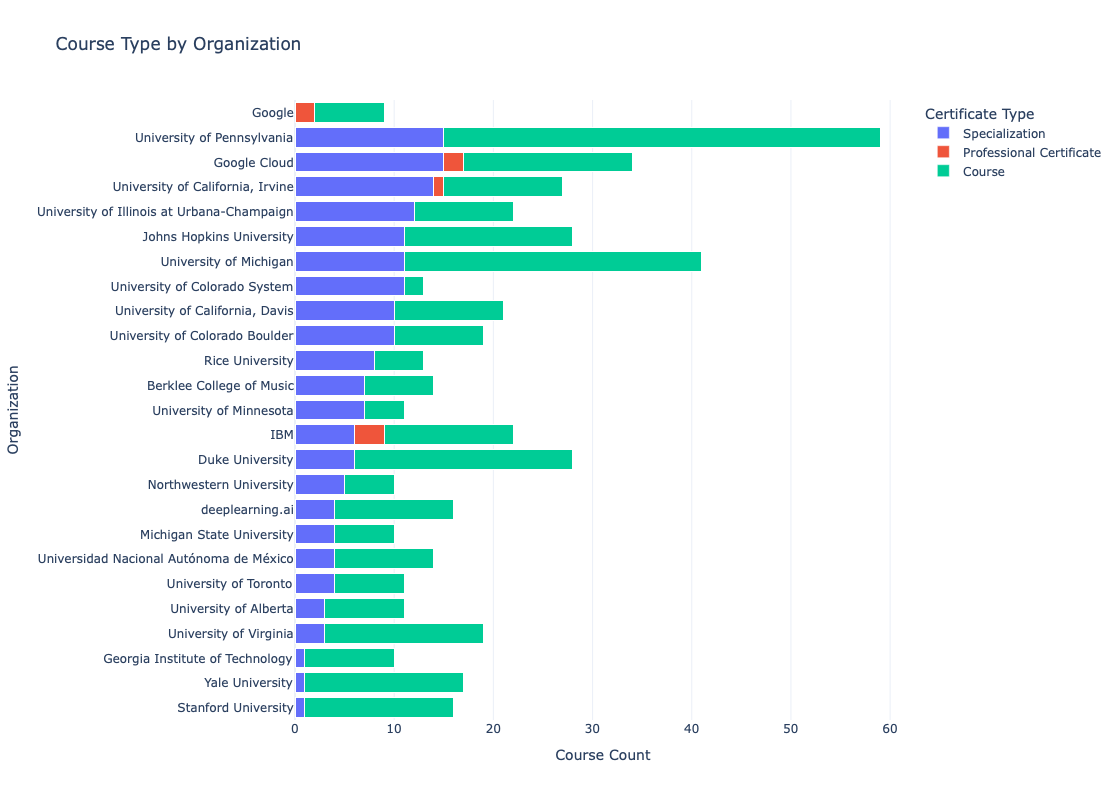

In [76]:
#  What types of courses are these organizations offering?
top25 = (csera_data['course_organization']
                .value_counts()
                .head(25))

filtered = csera_data[csera_data['course_organization'].isin(top25.index)]
counts = (filtered
			.groupby(['course_organization', 'certificate_type'])
            .agg(course_count=('course_title','count'))
			.reset_index())

counts = counts.sort_values('course_count', ascending=True)

fig = px.bar(counts,
       x = 'course_count',
       y = 'course_organization',
       color = 'certificate_type',  
       orientation = 'h',
       barmode = 'stack', 
       title = 'Course Type by Organization',
       labels = {
           'course_organization':'Organization',
           'certificate_type':'Certificate Type',
           'course_count': 'Course Count',
           'course_title': 'Course Title'
       },
        template = 'plotly_white', 
        width = 1000,
        height = 800
       )
fig.show()

**Courses are the majority of course types**
* While courses represent the majority of course types, this area could be further explored with respect to specializations. What is the relationship between courses and specializations? How do they relate as far as enrollment? 

### Course Ratings

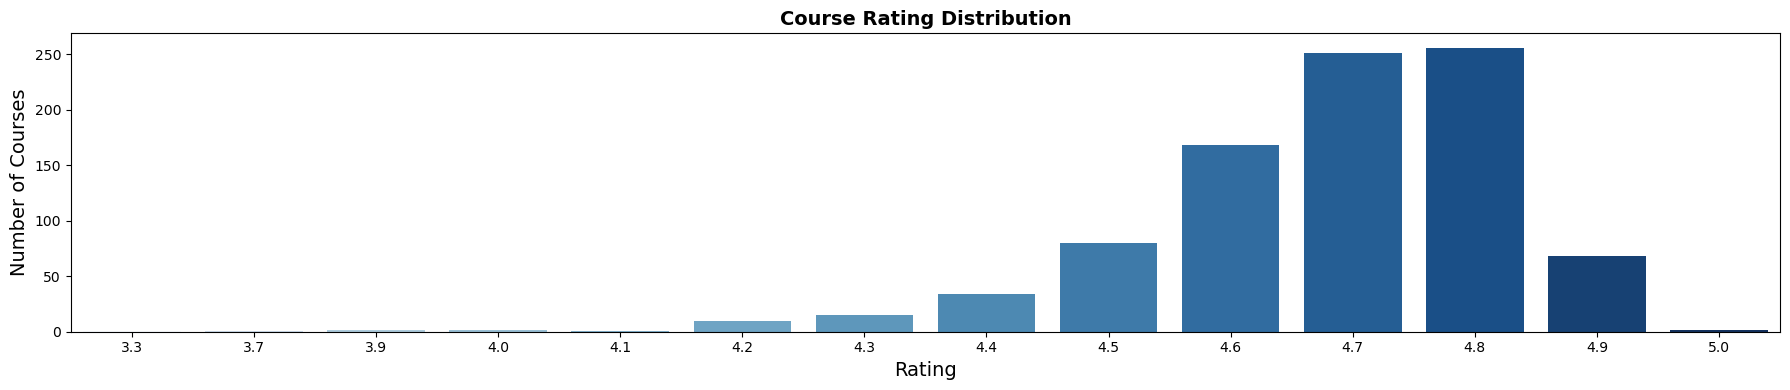

In [77]:
# What is the range of course ratings?
rating_data = csera_data['course_rating'].value_counts().reset_index()
rating_data.columns = ['ratings','counts']

fig, ax = plt.subplots(figsize=(18, 4))
sns.barplot(
    data=rating_data, 
    x='ratings', 
    y='counts',  
    hue='ratings',
    palette='Blues', 
    legend=False, ax=ax
)

ax.set_title('Course Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating', fontsize = 14)
ax.set_ylabel('Number of Courses', fontsize = 14)

plt.tight_layout()
plt.show()

**Course ratings tend to cluster between 4.6 and 4.8**
* One thing that may be interesting to explore further is what feedback tends to be correlated with various course rating bins, such as 4.1 and below4.2 - 4.5, 4.6 - 4.8, and 4.9 - 5.0. 

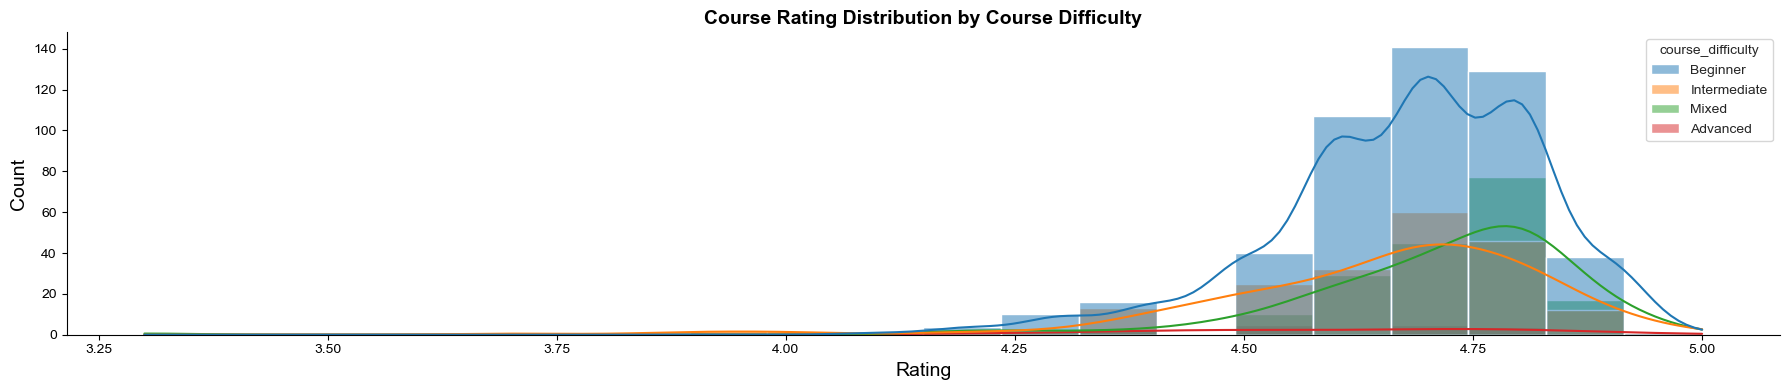

In [78]:
#  What is the range of ratings by course difficulty?
fig, ax = plt.subplots(figsize = (18,4))
sns.set_style("whitegrid")
sns.histplot(
    data = csera_data, 
    x = 'course_rating', 
    hue = 'course_difficulty',
    bins = 20,
    alpha = 0.5,
    kde = True,
    ax = ax
)

sns.despine()

ax.set_title('Course Rating Distribution by Course Difficulty', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating', fontsize = 14)
ax.set_ylabel('Count', fontsize = 14)

plt.tight_layout()
plt.show()

**The majority of courses are beginner and they are rated well**
* There are also a good number of mixed and intermediate courses, which also tend to be well rated, although the slope for beginner is more pronounced and robust. There are less advanced courses and the rating on them is relatively flat across the rating range. It seems that people are drawn to cousera for new learning. 

### Course Titles and Keywords

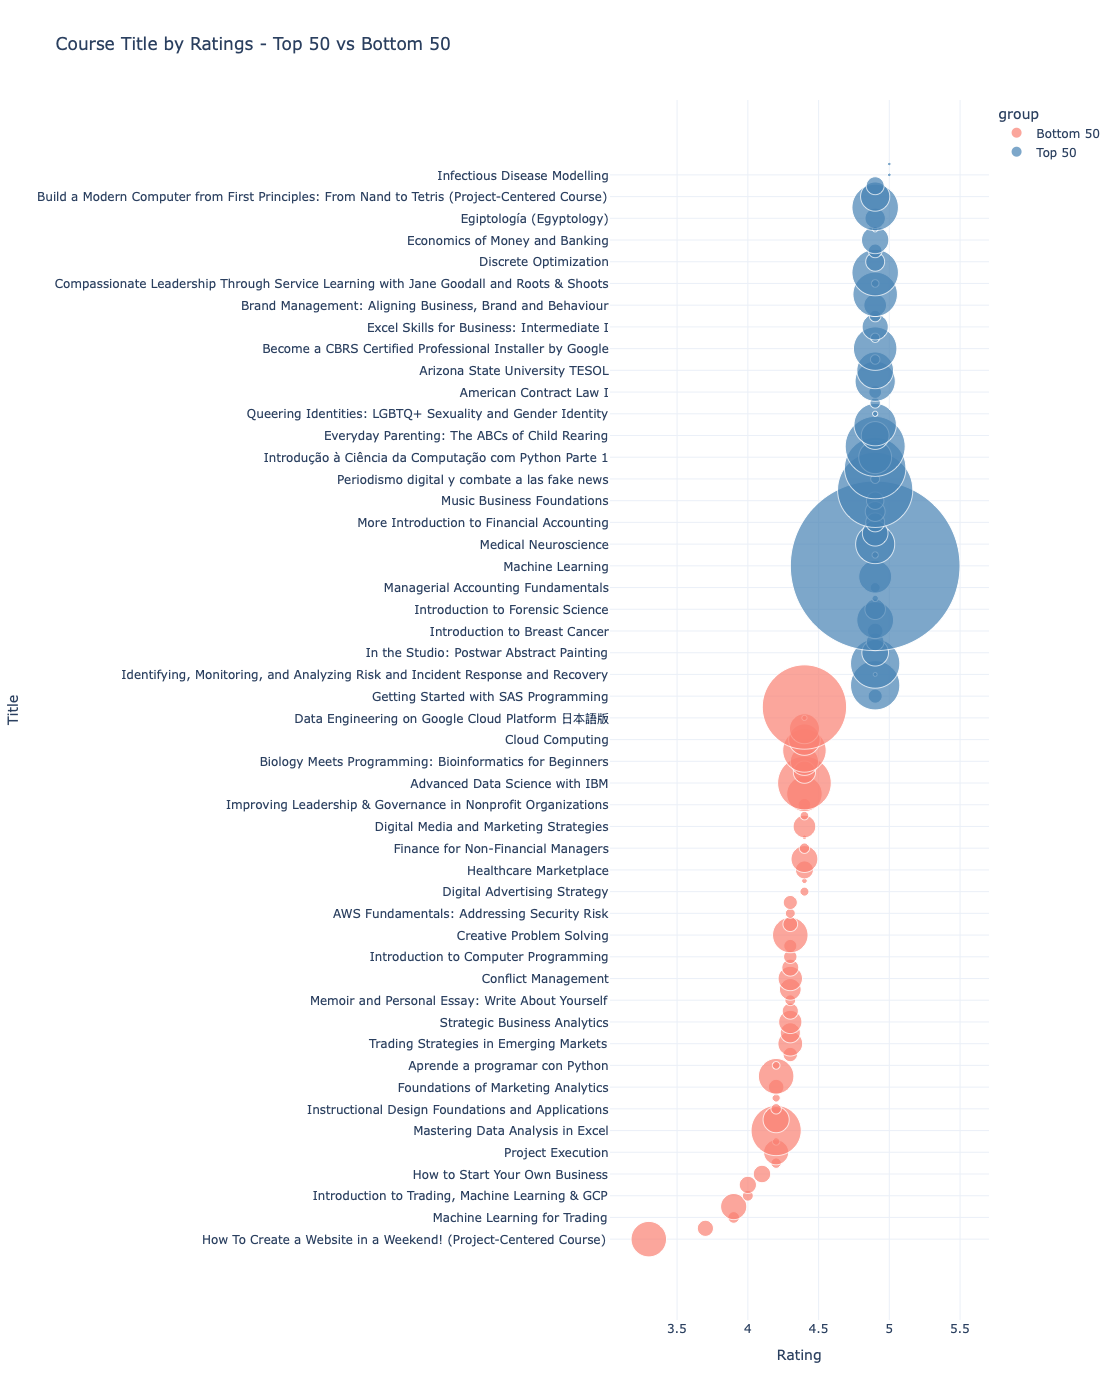

In [79]:
# What are the course titles of the top and bottom 50 rated courses?

top50 = (
    csera_data
    .nlargest(50, 'course_rating')
    .assign(group='Top 50')
)

bottom50 = (
    csera_data
    .nsmallest(50, 'course_rating')
    .assign(group='Bottom 50')
)

combined = (
    pd.concat([bottom50, top50], ignore_index=True)
    .sort_values('course_rating')
)

fig = px.scatter(
    combined,
    x='course_rating',
    y='course_title',
    color='group',
    size='students_enrolled',
    size_max=120,
    hover_name='course_title',
    hover_data=[
        'course_organization',
        'course_difficulty',
        'students_enrolled'
    ],
    color_discrete_map={
        'Top 50': 'steelblue',
        'Bottom 50': 'salmon',
    },
    labels={
        'course_rating': 'Rating',
        'course_title': 'Title',
        'course_organization': 'Organization',
        'course_difficulty': 'Course Difficulty',
        'students_enrolled': 'Enrollment'
    },
    title='Course Title by Ratings - Top 50 vs Bottom 50',
    template='plotly_white',
    width=1200,
    height=1400
)

fig.show()
              

**Popularity and rating may be correlated but not directly**
* While some of the highest rated courses have high enrollment, there are some lower rated courses that also have good enrollment. This might present various questions, such as if certain low-rated courses are required? Or do some courses consistently have good enrollment despite not being the most highly rated? 

### Course Enrollment

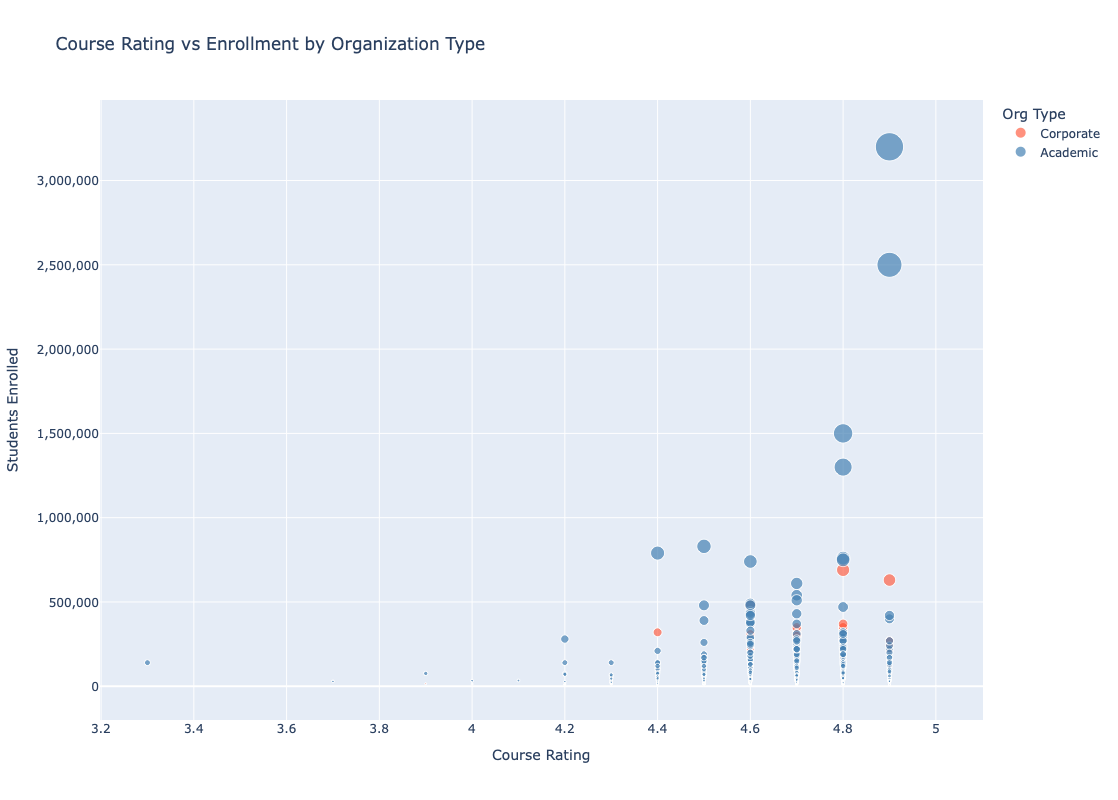

In [80]:
# What is the course enrollment by organization type and course rating?

academic_keywords = 'university|college|institute|school|academy'

csera_data['org_type'] = np.where(
    csera_data['course_organization'].str.contains(academic_keywords, case=False, na=False),
    'Academic',
    'Corporate'
)

fig = px.scatter(
    csera_data, 
    x="course_rating", 
    y="students_enrolled", 
    color="org_type",                         
    color_discrete_map={
        'Academic': 'steelblue',
        'Corporate': 'tomato'
    },
    size= 'students_enrolled',
    hover_name='course_title',
    hover_data= ['course_organization','course_difficulty','org_type'],
    title= 'Course Rating vs Enrollment by Organization Type',
    labels={
        'course_rating': 'Course Rating',
        'students_enrolled': 'Students Enrolled',
        'course_organization': 'Organization',
        'course_difficulty': 'Difficulty',
        'org_type': 'Org Type'
    },
    template= 'plotly',
    width= 1000,    
    height= 800     
)

fig.update_layout(
    yaxis=dict(
        dtick=500000,                         
        tickformat=',.0f'    
    )
)

fig.show()

**Courses from academic organization are prevalent**
* Academic organizations are supporting high levels of enrollment. Additionally, while we have seen a few views that touched on enrollment and course rating, this view can be very helpful to visualize courses of the same rating by enrollment and other factors. 

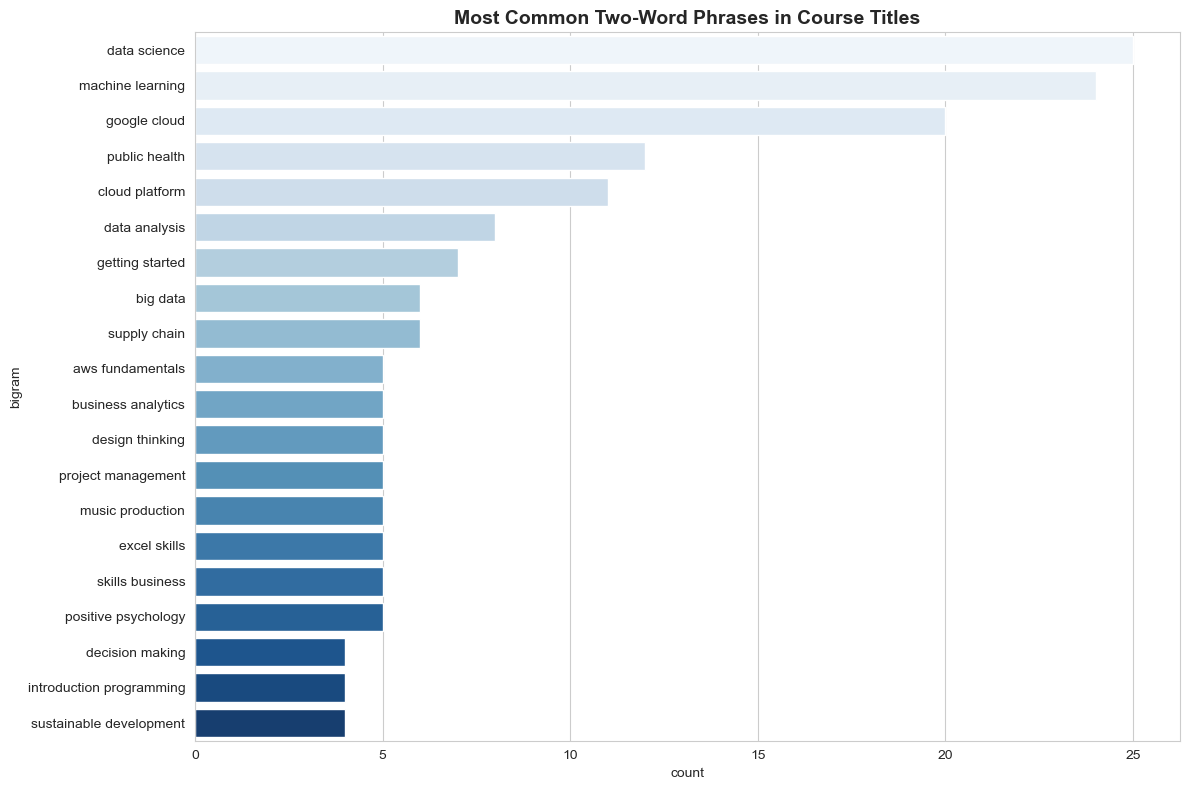

In [81]:
# What are the most common two word phrases found in course titles?
from collections import Counter
import re

def get_bigrams(text_series):
    """Extract lowercase word-pairs (bigrams) from a text series, excluding stopwords."""
    # Note: uses a plain Python loop rather than a vectorized approach — fine at
    # this dataset's size (891 rows), but wouldn't scale to a much larger dataset.
    bigrams = []
    stopwords = {'and','the','for','to','of','in','a','an','with','using','your','how'}
    for title in text_series.str.lower():
        words = [w for w in re.findall(r'\b\w+\b', title) if w not in stopwords and len(w) > 2]
        bigrams.extend(zip(words, words[1:]))
    return bigrams

bigrams = get_bigrams(csera_data['course_title'])
top_bigrams = pd.DataFrame(Counter(bigrams).most_common(20), columns=['bigram', 'count'])
top_bigrams['bigram'] = top_bigrams['bigram'].apply(lambda x: f"{x[0]} {x[1]}")
top_bigram_phrases = top_bigrams['bigram'].tolist()

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_bigrams, 
            x='count', 
            y='bigram', 
            hue='bigram', 
            palette='Blues', 
            legend=False,
            ax=ax)
ax.set_title('Most Common Two-Word Phrases in Course Titles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**'Data science', 'machine learning', and 'google cloud' are the most common phrases in course titles**
* There are also other meaningful two word phrases. A further exploration would be to work with the marketing team to find out if these phrases drive search and funnel into conversions. This particular code was also difficult. I knew what I wanted to do, but didn't know how to code it. I leaned heavily on AI for this code syntax and did not include it in the inital final version, but was encouraged to by the JTL reviewer to include it here. Along with these phrases, it's also important to note that a few of the largest enrollments from the previous query, like "well-being" and "python" are not accounted for in the two word key phrases.

In [82]:
# What is the enrollment for the courses with the most common two word phases?

# --- Function ---
def find_bigram(title):
    """Return the first known top bigram phrase found in a title, or 'other' if none match."""
    title = str(title).lower()
    return next((p for p in top_bigram_phrases if p in title), 'other')


# --- Ensure column exists ---
if 'title_bigram' not in csera_data.columns:
    csera_data['title_bigram'] = csera_data['course_title'].apply(find_bigram)


# --- Aggregate ---
bigram_counts = (
    csera_data
    .loc[lambda df: df['title_bigram'] != 'other']
    .groupby('title_bigram', as_index=False)
    .agg(
        course_count=('course_title', 'count'),
        total_enrolled=('students_enrolled', 'sum'),
        avg_rating=('course_rating', 'mean')
    )
    .sort_values('total_enrolled', ascending=False)
    .head(20)
)

# --- Format output ---
bigram_counts.index = range(1, len(bigram_counts) + 1)

bigram_counts = bigram_counts.rename(columns={
    'title_bigram': 'Topic Phrase',
    'course_count': 'Number of Courses',
    'total_enrolled': 'Total Enrolled',
    'avg_rating': 'Avg Rating'
})

# --- Styling ---
styled_table = (
    bigram_counts.style
    .format({
        'Total Enrolled': '{:,.0f}',
        'Avg Rating': '{:.2f}'
    })
    .background_gradient(subset=['Total Enrolled'], cmap='Blues')
)

styled_table

,Topic Phrase,Number of Courses,Total Enrolled,Avg Rating
1,data science,25,"5,812,000",4.58
2,machine learning,23,"5,502,000",4.50
3,google cloud,17,"1,683,200",4.65
4,getting started,6,"1,533,000",4.65
5,data analysis,7,"914,000",4.60
6,project management,5,"780,000",4.68
7,excel skills,5,"594,000",4.84
8,business analytics,5,"434,600",4.54
9,positive psychology,5,"382,000",4.74
10,design thinking,5,"368,000",4.64


**'Data science' and 'machine learning' are driving robust enrollment numbers**
* Courses with these key words are related to major enrollment numbers. More exploration could be done understand how these relate to total and average enrollment. This particular code was difficult. I knew what I wanted to do, but didn't know how to code it. I leaned heavily on AI for this code syntax and did not include it in the inital final version, but was encouraged to by the JTL reviewer to include it here to connect to the insights. 